<a href="https://colab.research.google.com/github/mohgeb/GlycemicPlus/blob/main/03_hybrid_glycemic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import random
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT = Path(
    "/content/drive/MyDrive/GlycemicSentinel"
)

DRIVE_DATA_DIR = PROJECT / "processed"
FEATURE_FILE = (
    PROJECT / "features/physiocgm_ppg_features.csv"
)

MODEL_DIR = PROJECT / "models"
RESULT_DIR = PROJECT / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [2]:
LOCAL_DATA_DIR = Path("/content/processed")
LOCAL_DATA_DIR.mkdir(exist_ok=True)

for src in DRIVE_DATA_DIR.glob("*.h5"):

    dst = LOCAL_DATA_DIR / src.name

    if not dst.exists():
        print("Copying:", src.name)
        shutil.copy2(src, dst)

DATA_DIR = LOCAL_DATA_DIR

print(
    "Local subjects:",
    len(list(DATA_DIR.glob("*.h5")))
)

Copying: c1s01.h5
Copying: c1s02.h5
Copying: c1s03.h5
Copying: c1s04.h5
Copying: c1s05.h5
Copying: c2s01.h5
Copying: c2s02.h5
Copying: c2s03.h5
Copying: c2s04.h5
Copying: c2s05.h5
Local subjects: 10


In [3]:
df = pd.read_csv(FEATURE_FILE)

print("Rows:", len(df))
print("Subjects:", df["subject"].nunique())

display(df.head())

Rows: 25600
Subjects: 10


,std,rms,iqr,ptp,skew,kurtosis,diff_std,diff_abs_mean,num_peaks,mean_ibi,...,power_0_5_1,power_1_2,power_2_4,power_4_8,dominant_frequency,subject,row,glucose,label,timestamp_ns
0,3.673937,3.674182,1.355473,56.572462,-0.491860,9.771661,0.596158,0.312427,421,0.719543,...,0.381812,0.404872,0.149951,0.025574,0.93750,c1s01,0,128.0,1,1654695828000000000
1,1.783247,1.783306,1.347651,21.327849,-0.269742,4.388167,0.304125,0.187797,408,0.724732,...,0.280663,0.485444,0.171969,0.026616,1.09375,c1s01,1,135.0,1,1654696128000000000
2,3.124286,3.124520,1.349844,55.089215,-1.162450,13.537554,0.549892,0.290202,450,0.647276,...,0.291827,0.434190,0.212777,0.028670,0.71875,c1s01,2,140.0,1,1654696727000000000
3,1.795799,1.795803,1.348946,33.329597,-0.005189,9.572604,0.376139,0.227918,494,0.613978,...,0.274044,0.437273,0.171349,0.072356,0.87500,c1s01,3,137.0,1,1654697027000000000
4,1.459353,1.459353,1.348582,17.865635,0.173923,3.678756,0.339529,0.238974,544,0.564589,...,0.270079,0.385067,0.206180,0.115748,0.81250,c1s01,4,134.0,1,1654697327000000000


In [4]:
split_frames = []

for subject, subject_df in df.groupby("subject"):

    subject_df = (
        subject_df
        .sort_values("timestamp_ns")
        .reset_index(drop=True)
        .copy()
    )

    n = len(subject_df)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    subject_df["split"] = "test"

    subject_df.loc[
        :train_end - 1,
        "split"
    ] = "train"

    subject_df.loc[
        train_end:val_end - 1,
        "split"
    ] = "val"

    split_frames.append(subject_df)


split_df = pd.concat(
    split_frames,
    ignore_index=True
)

display(
    pd.crosstab(
        split_df["subject"],
        split_df["split"]
    )
)

split,test,train,val
subject,,,
c1s01,319,1486,319
c1s02,389,1814,389
c1s03,383,1785,382
c1s04,322,1501,322
c1s05,412,1921,412
c2s01,443,2062,442
c2s02,315,1468,315
c2s03,331,1541,330
c2s04,471,2197,471


In [5]:
for subject in sorted(
    split_df["subject"].unique()
):

    s = split_df[
        split_df["subject"] == subject
    ]

    train_max = s.loc[
        s["split"] == "train",
        "timestamp_ns"
    ].max()

    val_min = s.loc[
        s["split"] == "val",
        "timestamp_ns"
    ].min()

    val_max = s.loc[
        s["split"] == "val",
        "timestamp_ns"
    ].max()

    test_min = s.loc[
        s["split"] == "test",
        "timestamp_ns"
    ].min()

    assert train_max < val_min
    assert val_max < test_min

print("✓ All 10 subjects split chronologically.")

✓ All 10 subjects split chronologically.


In [6]:
display(
    pd.crosstab(
        split_df["split"],
        split_df["label"]
    )
)

label,0,1,2
split,,,
test,208,3277,359
train,568,15017,2330
val,118,3145,578


In [7]:
for split in ["train", "val", "test"]:

    temp = split_df[
        split_df["split"] == split
    ]

    print("\n", split.upper())

    print(
        temp["label"]
        .value_counts()
        .sort_index()
    )


 TRAIN
label
0      568
1    15017
2     2330
Name: count, dtype: int64

 VAL
label
0     118
1    3145
2     578
Name: count, dtype: int64

 TEST
label
0     208
1    3277
2     359
Name: count, dtype: int64


In [8]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [9]:
META_COLUMNS = [
    "subject",
    "row",
    "glucose",
    "label",
    "timestamp_ns",
    "split"
]

feature_columns = [
    c for c in split_df.columns
    if c not in META_COLUMNS
]

print("Number of engineered features:",
      len(feature_columns))

Number of engineered features: 18


In [10]:
tree_train = split_df[
    split_df["split"] == "train"
].copy()

tree_val = split_df[
    split_df["split"] == "val"
].copy()

tree_test = split_df[
    split_df["split"] == "test"
].copy()


X_train_tree = tree_train[feature_columns]
y_train_tree = tree_train["label"]

X_val_tree = tree_val[feature_columns]
y_val_tree = tree_val["label"]

X_test_tree = tree_test[feature_columns]
y_test_tree = tree_test["label"]

In [11]:
train_medians = X_train_tree.median()

X_train_tree = X_train_tree.fillna(
    train_medians
)

X_val_tree = X_val_tree.fillna(
    train_medians
)

X_test_tree = X_test_tree.fillna(
    train_medians
)

In [12]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=700,
    depth=7,
    learning_rate=0.05,

    loss_function="MultiClass",

    auto_class_weights="Balanced",

    random_seed=42,

    verbose=100,
    allow_writing_files=False
)

cat_model.fit(
    X_train_tree,
    y_train_tree,

    eval_set=(
        X_val_tree,
        y_val_tree
    ),

    early_stopping_rounds=60,
    use_best_model=True
)

0:	learn: 1.0954978	test: 1.0968718	best: 1.0968718 (0)	total: 130ms	remaining: 1m 30s
100:	learn: 0.9409081	test: 1.0680089	best: 1.0663718 (82)	total: 8.52s	remaining: 50.5s
Stopped by overfitting detector  (60 iterations wait)

bestTest = 1.06397237
bestIteration = 124

Shrink model to first 125 iterations.


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=7, iterations=700, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [13]:
cat_val_prob = cat_model.predict_proba(
    X_val_tree
)

cat_test_prob = cat_model.predict_proba(
    X_test_tree
)

cat_test_pred = np.argmax(
    cat_test_prob,
    axis=1
)

print(
    classification_report(
        y_test_tree,
        cat_test_pred,
        target_names=[
            "Hypoglycemia",
            "In Range",
            "Hyperglycemia"
        ],
        digits=4,
        zero_division=0
    )
)

print(
    "CatBoost Macro F1:",
    round(
        f1_score(
            y_test_tree,
            cat_test_pred,
            average="macro"
        ),
        4
    )
)

print(
    "CatBoost Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test_tree,
            cat_test_pred
        ),
        4
    )
)

               precision    recall  f1-score   support

 Hypoglycemia     0.0699    0.2548    0.1097       208
     In Range     0.8528    0.4156    0.5589      3277
Hyperglycemia     0.1001    0.4150    0.1613       359

     accuracy                         0.4069      3844
    macro avg     0.3409    0.3618    0.2766      3844
 weighted avg     0.7402    0.4069    0.4974      3844

CatBoost Macro F1: 0.2766
CatBoost Balanced Accuracy: 0.3618


In [14]:
class PPGSplitDataset(Dataset):

    def __init__(self, split_dataframe, data_dir):

        self.df = (
            split_dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.data_dir = Path(data_dir)

        self.handles = {}

    def __len__(self):
        return len(self.df)

    def _get_handle(self, subject):

        if subject not in self.handles:

            path = (
                self.data_dir /
                f"{subject}.h5"
            )

            self.handles[subject] = (
                h5py.File(path, "r")
            )

        return self.handles[subject]

    def __getitem__(self, idx):

        record = self.df.iloc[idx]

        subject = record["subject"]
        row = int(record["row"])

        h5 = self._get_handle(subject)

        x = h5["ppg"][row].astype(
            np.float32
        )

        y = int(record["label"])

        # robust window normalization
        median = np.median(x)

        mad = np.median(
            np.abs(x - median)
        )

        scale = 1.4826 * mad

        if scale < 1e-6:
            scale = 1.0

        x = (x - median) / scale

        x = np.clip(
            x,
            -10,
            10
        )

        x = torch.from_numpy(
            x
        ).unsqueeze(0)

        return (
            x.float(),
            torch.tensor(
                y,
                dtype=torch.long
            )
        )

In [15]:
train_rows = split_df[
    split_df["split"] == "train"
]

val_rows = split_df[
    split_df["split"] == "val"
]

test_rows = split_df[
    split_df["split"] == "test"
]


train_dataset = PPGSplitDataset(
    train_rows,
    DATA_DIR
)

val_dataset = PPGSplitDataset(
    val_rows,
    DATA_DIR
)

test_dataset = PPGSplitDataset(
    test_rows,
    DATA_DIR
)


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

17915 3841 3844


In [16]:
train_labels = train_rows[
    "label"
].to_numpy()

counts = np.bincount(
    train_labels,
    minlength=3
)

weights = (
    len(train_labels) /
    (3 * counts)
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

print("Counts:", counts)
print("Weights:", class_weights)

Counts: [  568 15017  2330]
Weights: tensor([10.5135,  0.3977,  2.5629], device='cuda:0')


In [17]:
class TCNBlock(nn.Module):

    def __init__(
        self,
        channels,
        dilation,
        dropout=0.15
    ):

        super().__init__()

        padding = (
            dilation * 2
        )

        self.net = nn.Sequential(

            nn.Conv1d(
                channels,
                channels,
                kernel_size=5,
                padding=padding,
                dilation=dilation
            ),

            nn.BatchNorm1d(
                channels
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Conv1d(
                channels,
                channels,
                kernel_size=5,
                padding=padding,
                dilation=dilation
            ),

            nn.BatchNorm1d(
                channels
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            )
        )

    def forward(self, x):

        return x + self.net(x)

In [18]:
class PPGTCN(nn.Module):

    def __init__(self):

        super().__init__()

        # Aggressive early downsampling:
        # 19200 → ~2400
        self.stem = nn.Sequential(

            nn.Conv1d(
                1,
                64,
                kernel_size=17,
                stride=8,
                padding=8
            ),

            nn.BatchNorm1d(64),
            nn.GELU()
        )

        self.tcn = nn.Sequential(

            TCNBlock(
                64,
                dilation=1
            ),

            TCNBlock(
                64,
                dilation=2
            ),

            TCNBlock(
                64,
                dilation=4
            ),

            TCNBlock(
                64,
                dilation=8
            ),

            TCNBlock(
                64,
                dilation=16
            )
        )

        self.avg_pool = (
            nn.AdaptiveAvgPool1d(1)
        )

        self.max_pool = (
            nn.AdaptiveMaxPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                128,
                64
            ),

            nn.GELU(),

            nn.Dropout(0.30),

            nn.Linear(
                64,
                3
            )
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.tcn(x)

        avg = self.avg_pool(x)
        mx = self.max_pool(x)

        x = torch.cat(
            [avg, mx],
            dim=1
        )

        x = x.squeeze(-1)

        return self.classifier(x)

In [19]:
tcn_model = PPGTCN().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    tcn_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )
)

print(tcn_model)

PPGTCN(
  (stem): Sequential(
    (0): Conv1d(1, 64, kernel_size=(17,), stride=(8,), padding=(8,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (tcn): Sequential(
    (0): TCNBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): GELU(approximate='none')
        (7): Dropout(p=0.15, inplace=False)
      )
    )
    (1): TCNBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, 

In [20]:
def evaluate_tcn(
    model,
    loader
):

    model.eval()

    y_true = []
    probs = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            logits = model(x)

            p = torch.softmax(
                logits,
                dim=1
            )

            probs.append(
                p.cpu().numpy()
            )

            y_true.extend(
                y.numpy()
            )

    probs = np.concatenate(
        probs
    )

    y_true = np.array(
        y_true
    )

    pred = np.argmax(
        probs,
        axis=1
    )

    return {
        "y_true": y_true,
        "prob": probs,
        "pred": pred,

        "macro_f1":
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            )
    }

In [21]:
EPOCHS = 12
PATIENCE = 3

best_f1 = -1
bad_epochs = 0

TCN_PATH = (
    MODEL_DIR /
    "ppg_tcn_personalized.pt"
)

for epoch in range(
    1,
    EPOCHS + 1
):

    tcn_model.train()

    total_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = tcn_model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() * len(y)
        )

    val_metrics = evaluate_tcn(
        tcn_model,
        val_loader
    )

    scheduler.step(
        val_metrics["macro_f1"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Loss "
        f"{total_loss/len(train_dataset):.4f} | "
        f"Val F1 "
        f"{val_metrics['macro_f1']:.4f} | "
        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f}"
    )

    if (
        val_metrics["macro_f1"]
        > best_f1
    ):

        best_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        bad_epochs = 0

        torch.save(
            tcn_model.state_dict(),
            TCN_PATH
        )

        print("  ✓ saved")

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:

            print("Early stopping.")
            break

Epoch 01 | Loss 1.1983 | Val F1 0.3065 | Val BalAcc 0.3306
  ✓ saved
Epoch 02 | Loss 1.0903 | Val F1 0.3000 | Val BalAcc 0.3330
Epoch 03 | Loss 1.0851 | Val F1 0.2285 | Val BalAcc 0.3246
Epoch 04 | Loss 1.0845 | Val F1 0.3346 | Val BalAcc 0.3417
  ✓ saved
Epoch 05 | Loss 1.0827 | Val F1 0.3425 | Val BalAcc 0.3721
  ✓ saved
Epoch 06 | Loss 1.0800 | Val F1 0.3357 | Val BalAcc 0.3416
Epoch 07 | Loss 1.0844 | Val F1 0.3346 | Val BalAcc 0.3297
Epoch 08 | Loss 1.0788 | Val F1 0.3372 | Val BalAcc 0.3405
Early stopping.


In [22]:
tcn_model.load_state_dict(
    torch.load(
        TCN_PATH,
        map_location=device
    )
)

tcn_val = evaluate_tcn(
    tcn_model,
    val_loader
)

tcn_test = evaluate_tcn(
    tcn_model,
    test_loader
)

print(
    "TCN TEST Macro F1:",
    round(
        tcn_test["macro_f1"],
        4
    )
)

print(
    "TCN TEST Balanced Accuracy:",
    round(
        tcn_test[
            "balanced_accuracy"
        ],
        4
    )
)

TCN TEST Macro F1: 0.308
TCN TEST Balanced Accuracy: 0.3528


In [23]:
best_alpha = None
best_score = -1

# alpha = weight given to TCN
for alpha in np.arange(
    0.0,
    1.01,
    0.05
):

    ensemble_val_prob = (
        alpha *
        tcn_val["prob"]
        +
        (1 - alpha) *
        cat_val_prob
    )

    pred = np.argmax(
        ensemble_val_prob,
        axis=1
    )

    score = f1_score(
        y_val_tree,
        pred,
        average="macro",
        zero_division=0
    )

    if score > best_score:

        best_score = score
        best_alpha = alpha


print(
    "Best TCN weight:",
    best_alpha
)

print(
    "Best validation Macro F1:",
    round(best_score, 4)
)

Best TCN weight: 0.75
Best validation Macro F1: 0.3495


In [24]:
ensemble_test_prob = (
    best_alpha *
    tcn_test["prob"]
    +
    (1 - best_alpha) *
    cat_test_prob
)

ensemble_pred = np.argmax(
    ensemble_test_prob,
    axis=1
)

print(
    classification_report(
        y_test_tree,
        ensemble_pred,
        target_names=[
            "Hypoglycemia",
            "In Range",
            "Hyperglycemia"
        ],
        digits=4,
        zero_division=0
    )
)

ensemble_f1 = f1_score(
    y_test_tree,
    ensemble_pred,
    average="macro",
    zero_division=0
)

ensemble_bal = balanced_accuracy_score(
    y_test_tree,
    ensemble_pred
)

print(
    "HYBRID Macro F1:",
    round(ensemble_f1, 4)
)

print(
    "HYBRID Balanced Accuracy:",
    round(ensemble_bal, 4)
)

               precision    recall  f1-score   support

 Hypoglycemia     0.3077    0.0769    0.1231       208
     In Range     0.8537    0.5679    0.6821      3277
Hyperglycemia     0.1110    0.4986    0.1816       359

     accuracy                         0.5349      3844
    macro avg     0.4241    0.3811    0.3289      3844
 weighted avg     0.7548    0.5349    0.6051      3844

HYBRID Macro F1: 0.3289
HYBRID Balanced Accuracy: 0.3811


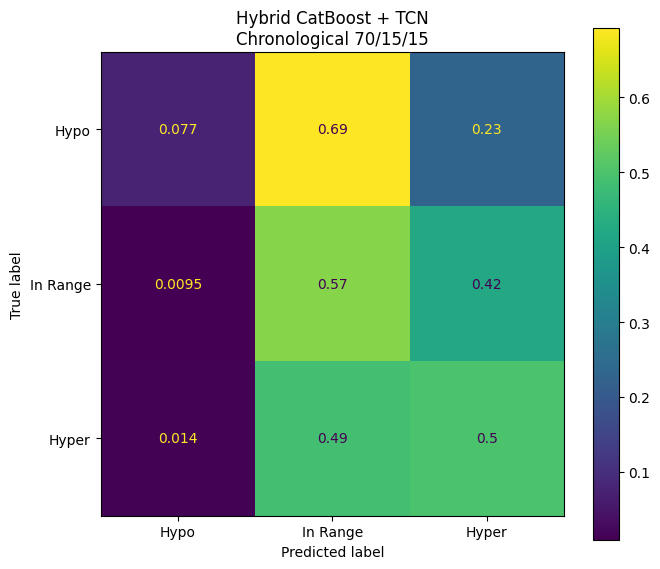

In [25]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_tree,
    ensemble_pred,

    display_labels=[
        "Hypo",
        "In Range",
        "Hyper"
    ],

    normalize="true",

    ax=ax
)

plt.title(
    "Hybrid CatBoost + TCN\n"
    "Chronological 70/15/15"
)

plt.tight_layout()
plt.show()

In [26]:
results = pd.DataFrame([
    {
        "model":
            "CatBoost",

        "macro_f1":
            f1_score(
                y_test_tree,
                cat_test_pred,
                average="macro"
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_test_tree,
                cat_test_pred
            )
    },

    {
        "model":
            "TCN",

        "macro_f1":
            tcn_test["macro_f1"],

        "balanced_accuracy":
            tcn_test[
                "balanced_accuracy"
            ]
    },

    {
        "model":
            "Hybrid",

        "macro_f1":
            ensemble_f1,

        "balanced_accuracy":
            ensemble_bal
    }
])

display(
    results.round(4)
)

results.to_csv(
    RESULT_DIR /
    "personalized_model_comparison.csv",
    index=False
)

,model,macro_f1,balanced_accuracy
0,CatBoost,0.2766,0.3618
1,TCN,0.3080,0.3528
2,Hybrid,0.3289,0.3811


In [27]:
# Validation ensemble probabilities
ensemble_val_prob = (
    best_alpha * tcn_val["prob"]
    +
    (1 - best_alpha) * cat_val_prob
)

y_val_np = np.asarray(y_val_tree)

best_score = -1
best_hypo_weight = None
best_hyper_weight = None

# Coarse search -- validation data ONLY
for hypo_weight in np.arange(0.5, 3.01, 0.1):

    for hyper_weight in np.arange(0.5, 3.01, 0.1):

        adjusted = ensemble_val_prob.copy()

        adjusted[:, 0] *= hypo_weight
        adjusted[:, 2] *= hyper_weight

        pred = np.argmax(
            adjusted,
            axis=1
        )

        score = f1_score(
            y_val_np,
            pred,
            average="macro",
            zero_division=0
        )

        if score > best_score:

            best_score = score
            best_hypo_weight = hypo_weight
            best_hyper_weight = hyper_weight


print(
    "Best validation Macro F1:",
    round(best_score, 4)
)

print(
    "Hypoglycemia decision weight:",
    round(best_hypo_weight, 2)
)

print(
    "Hyperglycemia decision weight:",
    round(best_hyper_weight, 2)
)

Best validation Macro F1: 0.3602
Hypoglycemia decision weight: 1.0
Hyperglycemia decision weight: 0.9


In [28]:
calibrated_test_prob = (
    ensemble_test_prob.copy()
)

calibrated_test_prob[:, 0] *= (
    best_hypo_weight
)

calibrated_test_prob[:, 2] *= (
    best_hyper_weight
)

calibrated_pred = np.argmax(
    calibrated_test_prob,
    axis=1
)

print(
    classification_report(
        y_test_tree,
        calibrated_pred,
        target_names=[
            "Hypoglycemia",
            "In Range",
            "Hyperglycemia"
        ],
        digits=4,
        zero_division=0
    )
)

calibrated_f1 = f1_score(
    y_test_tree,
    calibrated_pred,
    average="macro",
    zero_division=0
)

calibrated_bal = balanced_accuracy_score(
    y_test_tree,
    calibrated_pred
)

print(
    "\nCalibrated Hybrid Macro F1:",
    round(calibrated_f1, 4)
)

print(
    "Calibrated Hybrid Balanced Accuracy:",
    round(calibrated_bal, 4)
)

               precision    recall  f1-score   support

 Hypoglycemia     0.3019    0.0769    0.1226       208
     In Range     0.8548    0.9161    0.8844      3277
Hyperglycemia     0.1039    0.0808    0.0909       359

     accuracy                         0.7927      3844
    macro avg     0.4202    0.3579    0.3660      3844
 weighted avg     0.7547    0.7927    0.7690      3844


Calibrated Hybrid Macro F1: 0.366
Calibrated Hybrid Balanced Accuracy: 0.3579


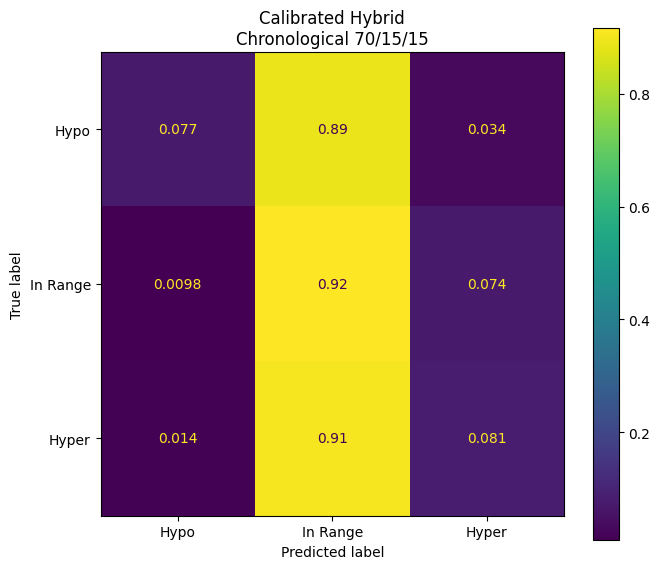

In [29]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_tree,
    calibrated_pred,

    display_labels=[
        "Hypo",
        "In Range",
        "Hyper"
    ],

    normalize="true",
    ax=ax
)

plt.title(
    "Calibrated Hybrid\n"
    "Chronological 70/15/15"
)

plt.tight_layout()
plt.show()

In [30]:
test_eval = tree_test.reset_index(drop=True).copy()

assert len(test_eval) == len(ensemble_test_prob)
assert len(test_eval) == len(tcn_test["y_true"])

assert np.array_equal(
    test_eval["label"].to_numpy(),
    tcn_test["y_true"]
)

print("✓ Prediction and CGM ground truth are aligned.")

✓ Prediction and CGM ground truth are aligned.


In [31]:
LABEL_NAMES = {
    0: "Hypoglycemia",
    1: "In Range",
    2: "Hyperglycemia"
}

test_eval["actual_label"] = (
    test_eval["label"]
    .map(LABEL_NAMES)
)

test_eval["predicted_code"] = ensemble_pred

test_eval["predicted_label"] = (
    test_eval["predicted_code"]
    .map(LABEL_NAMES)
)

test_eval["p_hypo"] = (
    ensemble_test_prob[:, 0]
)

test_eval["p_normal"] = (
    ensemble_test_prob[:, 1]
)

test_eval["p_hyper"] = (
    ensemble_test_prob[:, 2]
)

test_eval["correct"] = (
    test_eval["label"]
    ==
    test_eval["predicted_code"]
)

display(
    test_eval[
        [
            "subject",
            "timestamp_ns",
            "glucose",
            "actual_label",
            "predicted_label",
            "p_hypo",
            "p_normal",
            "p_hyper",
            "correct"
        ]
    ].head(20)
)

,subject,timestamp_ns,glucose,actual_label,predicted_label,p_hypo,p_normal,p_hyper,correct
0,c1s01,1656235203000000000,87.0,In Range,Hyperglycemia,0.277782,0.360064,0.362153,False
1,c1s01,1656235503000000000,80.0,In Range,Hyperglycemia,0.282950,0.353212,0.363838,False
2,c1s01,1656235803000000000,73.0,In Range,Hyperglycemia,0.304810,0.344584,0.350606,False
3,c1s01,1656236103000000000,66.0,Hypoglycemia,In Range,0.286713,0.357073,0.356214,False
4,c1s01,1656236403000000000,63.0,Hypoglycemia,Hyperglycemia,0.281818,0.356810,0.361372,False
5,c1s01,1656236703000000000,63.0,Hypoglycemia,Hyperglycemia,0.260202,0.356213,0.383586,False
6,c1s01,1656237003000000000,73.0,In Range,In Range,0.261683,0.384061,0.354256,True
7,c1s01,1656237303000000000,89.0,In Range,Hyperglycemia,0.279195,0.354013,0.366792,False
8,c1s01,1656237604000000000,117.0,In Range,In Range,0.269283,0.369953,0.360764,True
9,c1s01,1656237904000000000,142.0,In Range,Hyperglycemia,0.273326,0.363331,0.363343,False


In [32]:
test_eval["confidence"] = (
    ensemble_test_prob.max(axis=1)
)

test_eval["actual_probability"] = [
    ensemble_test_prob[i, int(label)]
    for i, label in enumerate(
        test_eval["label"].to_numpy()
    )
]

display(
    test_eval[
        [
            "subject",
            "glucose",
            "actual_label",
            "predicted_label",
            "confidence",
            "actual_probability",
            "correct"
        ]
    ].head(20)
)

,subject,glucose,actual_label,predicted_label,confidence,actual_probability,correct
0,c1s01,87.0,In Range,Hyperglycemia,0.362153,0.360064,False
1,c1s01,80.0,In Range,Hyperglycemia,0.363838,0.353212,False
2,c1s01,73.0,In Range,Hyperglycemia,0.350606,0.344584,False
3,c1s01,66.0,Hypoglycemia,In Range,0.357073,0.286713,False
4,c1s01,63.0,Hypoglycemia,Hyperglycemia,0.361372,0.281818,False
5,c1s01,63.0,Hypoglycemia,Hyperglycemia,0.383586,0.260202,False
6,c1s01,73.0,In Range,In Range,0.384061,0.384061,True
7,c1s01,89.0,In Range,Hyperglycemia,0.366792,0.354013,False
8,c1s01,117.0,In Range,In Range,0.369953,0.369953,True
9,c1s01,142.0,In Range,Hyperglycemia,0.363343,0.363331,False


In [33]:
COMPARISON_FILE = (
    RESULT_DIR /
    "hybrid_ground_truth_comparison.csv"
)

test_eval.to_csv(
    COMPARISON_FILE,
    index=False
)

print("Saved:")
print(COMPARISON_FILE)

Saved:
/content/drive/MyDrive/GlycemicSentinel/results/hybrid_ground_truth_comparison.csv


In [34]:
ensemble_config = pd.DataFrame([{
    "tcn_weight": best_alpha,
    "catboost_weight": 1 - best_alpha,
    "macro_f1": ensemble_f1,
    "balanced_accuracy": ensemble_bal
}])

ensemble_config.to_csv(
    RESULT_DIR /
    "hybrid_ensemble_config.csv",
    index=False
)

display(ensemble_config)

,tcn_weight,catboost_weight,macro_f1,balanced_accuracy
0,0.75,0.25,0.328923,0.381143
